In [63]:
import os
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from binsreg import binsreg
from sklearn.linear_model import LinearRegression

In [64]:
data_path = Path(os.environ["DATA_PATH"])

In [65]:
df_voids = (
    gpd.read_file(data_path / "baldios")
    .to_crs("EPSG:6372")
    .assign(geometry=lambda df: df["geometry"].force_2d())
)

df = (
    gpd.read_file(data_path / "baldios.geojson")
    .to_crs("EPSG:6372")
    .rename(columns={"urban_void_count": "void_count"})
    .assign(
        void_count=lambda df: (
            df["void_count"].replace("No Disponible", np.nan).astype(float)
        ),
    )
)

overlay_area = (
    df[["geometry"]]
    .reset_index(names="index_left")
    .overlay(df_voids[["geometry"]], how="intersection")
    .assign(area=lambda df: df["geometry"].area)
    .groupby("index_left")
    .agg(void_area=("area", "sum"))
)

df = (
    df.join(overlay_area)
    .assign(void_frac=lambda df: df["void_area"] / df["geometry"].area)
    .query("void_frac <= 1")
)

/Users/rodolfofigueroa/Documents/mexicali-zone/.venv/lib/python3.11/site-packages/geopandas/geodataframe.py:2675: UserWarning: `keep_geom_type=True` in overlay resulted in 2 dropped geometries of different geometry types than df1 has. Set `keep_geom_type=False` to retain all geometries


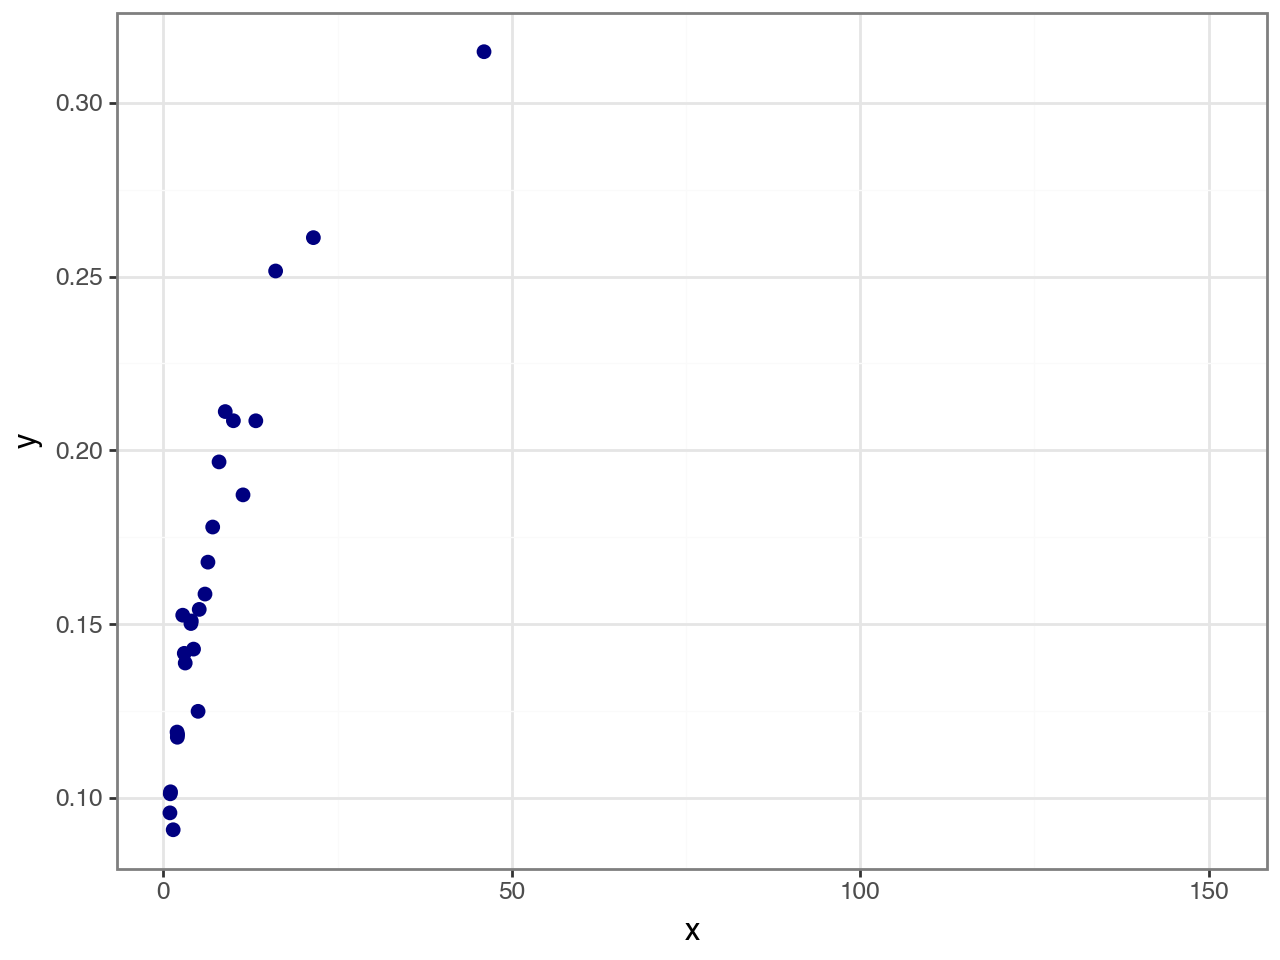

In [80]:
temp = df.dropna(subset=["void_count", "void_frac"]).query(
    "void_count > 0",
)

x = temp["void_count"].to_numpy()

rng = np.random.default_rng(42)
offset = rng.normal(0, 0.05, size=x.shape[0]).flatten()
x_offset = x + offset

y = temp["void_frac"].to_numpy()
reg = binsreg(y, x_offset)

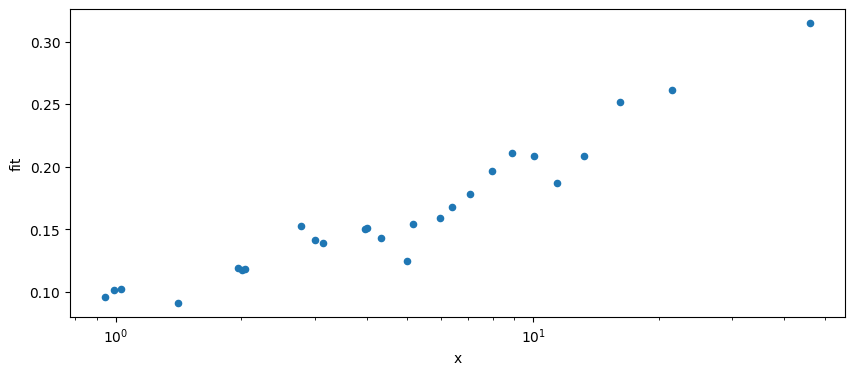

In [84]:
fig, ax = plt.subplots(figsize=(10, 4))
reg.data_plot[0].dots.plot.scatter(x="x", y="fit", ax=ax)
ax.set_xscale("log")

In [72]:
temp = df.dropna(subset=["void_count", "dust_index"]).query(
    "void_count > 0",
)
X = temp["void_count"].to_numpy().reshape(-1, 1)
y = temp["dust_index"].to_numpy()

model = LinearRegression()
model.fit(X, y)

LinearRegression()

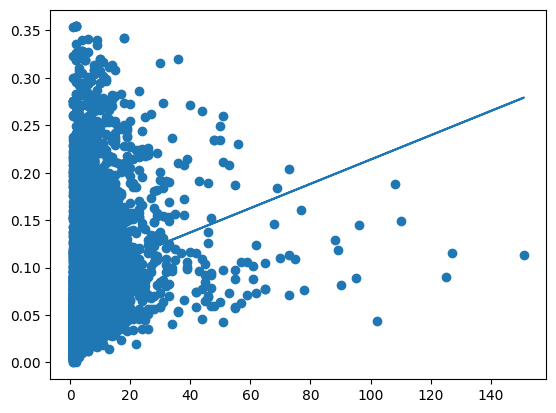

In [73]:
yhat = model.predict(X)

plt.scatter(X, y)
plt.plot(X, yhat)

In [74]:
rng = np.random.default_rng(42)
offset = rng.normal(0, 0.05, size=X.shape[0])
Xtest = X + offset.reshape(-1, 1)

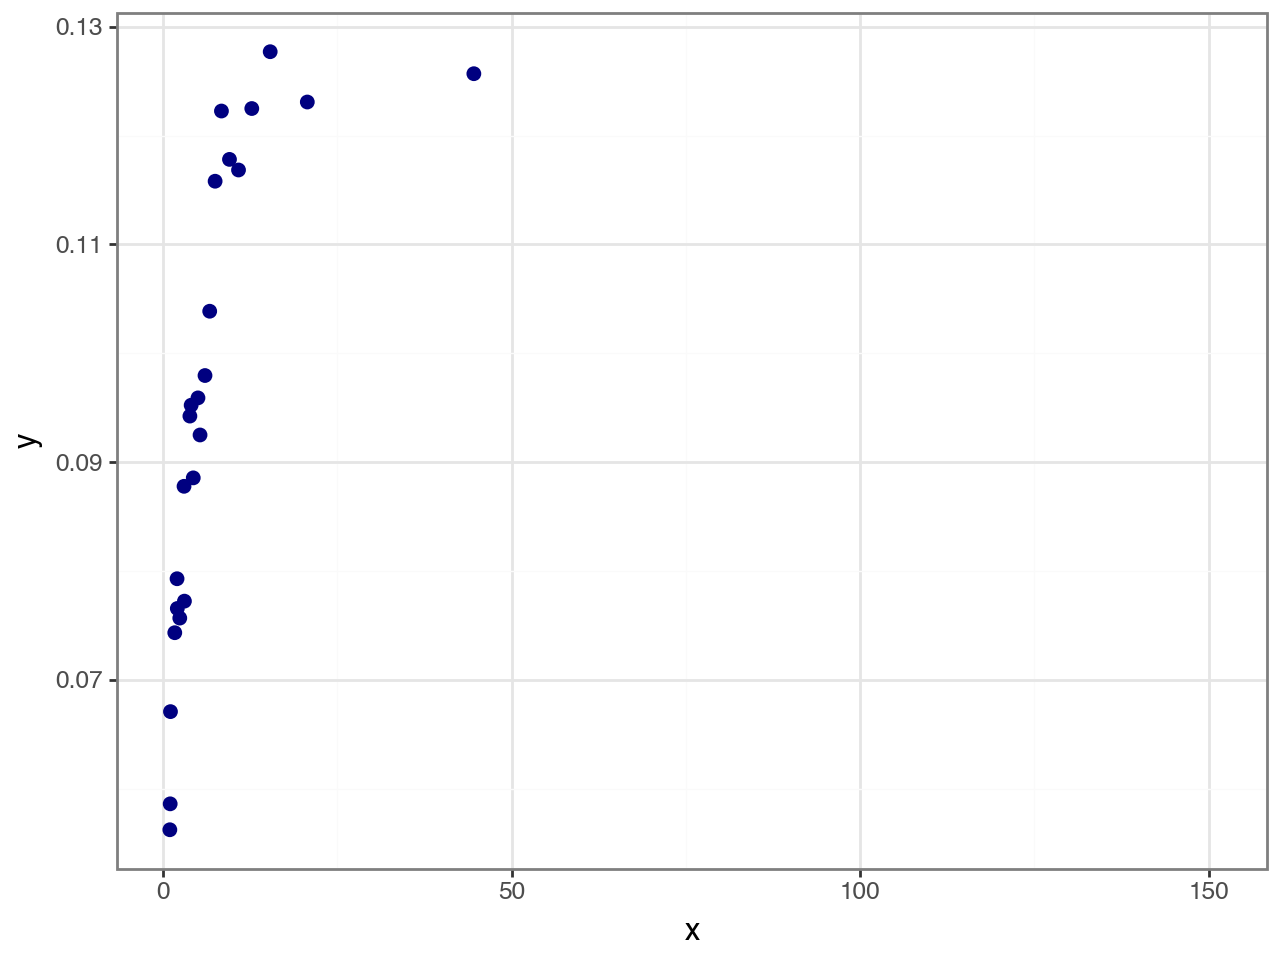

In [75]:
reg = binsreg(y, Xtest.flatten(), randcut=1, at="median")

In [76]:
df_reg = reg.data_plot[0].dots
df_reg = df_reg.assign(xlog=lambda df: df["x"].apply(lambda x: np.log10(x)))

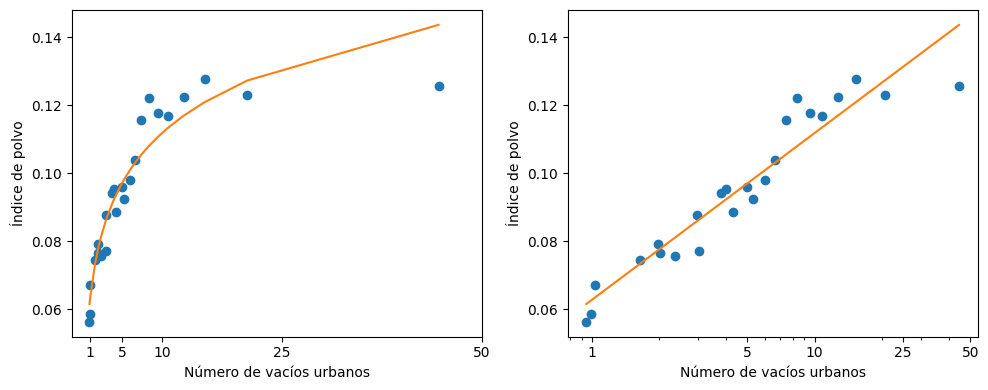

In [103]:
model = LinearRegression().fit(df_reg[["xlog"]], df_reg["fit"])

fig, (axl, axr) = plt.subplots(1, 2, figsize=(10, 4))

for scale, ax in zip(["linear", "log"], [axl, axr]):
    ax.scatter(df_reg["x"], df_reg["fit"], label="Binned averages", color="C0")
    ax.plot(df_reg["x"], model.predict(df_reg[["xlog"]]), color="C1")
    ax.set_xlabel("Número de vacíos urbanos")
    ax.set_ylabel("Índice de polvo")

    ax.set_xscale(scale)
    ax.set_xticks([1, 5, 10, 25, 50])
    ax.set_xticklabels([1, 5, 10, 25, 50], rotation=0)

fig.tight_layout()

In [104]:
model.coef_

array([0.04913269])